In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder

In [2]:
df=pd.read_csv('loan_data.csv')

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
x=df.drop(columns='loan_status')
y=df['loan_status']

In [7]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [8]:
x.corr(numeric_only=True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'person_age'),
  Text(1, 0, 'person_income'),
  Text(2, 0, 'person_emp_exp'),
  Text(3, 0, 'loan_amnt'),
  Text(4, 0, 'loan_int_rate'),
  Text(5, 0, 'loan_percent_income'),
  Text(6, 0, 'cb_person_cred_hist_length'),
  Text(7, 0, 'credit_score')])

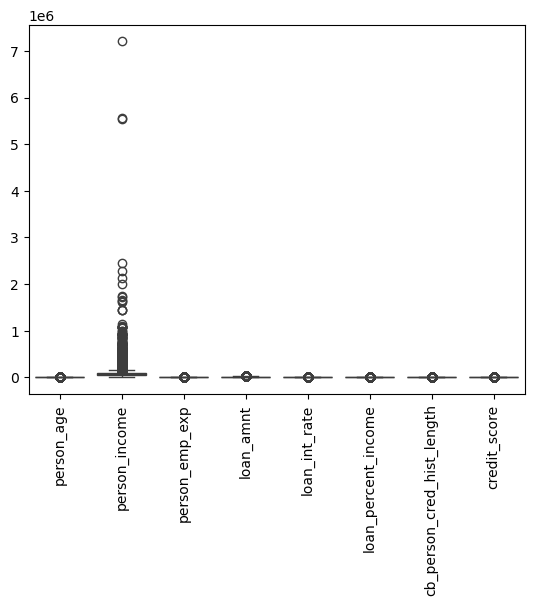

In [11]:
a=sns.boxplot(x[num_cols])
plt.xticks(rotation=90)

In [12]:
x[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

In [13]:
robust_sclaer=RobustScaler()
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

# Scaling

In [14]:
x_train[num_cols]=robust_sclaer.fit_transform(x_train[num_cols])
x_test[num_cols]=robust_sclaer.transform(x_test[num_cols])

In [15]:
x_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,1.333333,female,Bachelor,0.621771,1.000000,MORTGAGE,0.965517,PERSONAL,0.386517,0.250000,1.0,-0.132353,No
12555,-0.166667,male,High School,0.120777,-0.142857,RENT,0.551724,VENTURE,0.191011,0.333333,0.0,0.279412,Yes
29153,2.500000,female,Master,5.265159,2.000000,MORTGAGE,2.206897,PERSONAL,-0.143820,-0.416667,1.4,0.632353,Yes
23838,0.166667,male,Associate,0.559271,0.000000,RENT,0.220690,EDUCATION,1.377528,-0.166667,0.6,0.014706,No
35686,0.166667,male,Master,0.366411,0.428571,RENT,-0.129793,HOMEIMPROVEMENT,0.440449,-0.333333,-0.2,0.970588,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,male,High School,0.440142,0.285714,MORTGAGE,0.362069,EDUCATION,-1.119101,0.000000,0.0,-1.191176,Yes
44732,-0.166667,female,High School,-0.666014,-0.142857,MORTGAGE,-0.292966,HOMEIMPROVEMENT,0.152809,0.416667,0.0,0.102941,No
38158,1.166667,female,Associate,-0.180825,0.714286,MORTGAGE,0.373379,VENTURE,-0.060674,0.500000,1.0,0.176471,Yes
860,0.000000,male,Master,2.297872,0.285714,RENT,1.655172,DEBTCONSOLIDATION,1.568539,-0.083333,-0.2,-0.529412,No


In [16]:
x_test

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
37979,1.000000,male,Associate,0.613528,0.857143,MORTGAGE,-0.068966,EDUCATION,-1.116854,-0.333333,1.2,-0.573529,No
9911,-0.333333,male,Associate,-0.211303,0.285714,RENT,0.137931,EDUCATION,0.107865,0.333333,0.0,0.102941,Yes
43386,-0.666667,female,Master,-0.613961,-0.571429,RENT,-0.413793,MEDICAL,0.869663,0.083333,0.0,1.044118,No
13822,-0.500000,female,Bachelor,-0.559435,-0.428571,OWN,-0.413793,VENTURE,0.669663,0.083333,-0.2,-0.632353,Yes
44810,2.666667,male,High School,0.018175,2.285714,MORTGAGE,0.275862,HOMEIMPROVEMENT,0.988764,0.250000,1.4,-0.794118,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,male,Bachelor,1.362382,-0.571429,MORTGAGE,0.827586,VENTURE,-0.229213,-0.083333,-0.4,0.205882,No
30384,2.166667,male,High School,-0.107218,1.857143,RENT,-0.175862,EDUCATION,1.222472,-0.083333,1.4,-0.500000,Yes
36665,-0.333333,female,Master,0.244356,-0.428571,RENT,0.827586,EDUCATION,0.143820,0.500000,-0.2,-0.382353,No
30569,2.000000,male,Associate,-0.617176,1.714286,RENT,0.000000,MEDICAL,0.000000,0.833333,2.0,0.808824,No


# Encoding

In [17]:
x_train[obj_cols]

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
25180,female,Bachelor,MORTGAGE,PERSONAL,No
12555,male,High School,RENT,VENTURE,Yes
29153,female,Master,MORTGAGE,PERSONAL,Yes
23838,male,Associate,RENT,EDUCATION,No
35686,male,Master,RENT,HOMEIMPROVEMENT,Yes
...,...,...,...,...,...
11284,male,High School,MORTGAGE,EDUCATION,Yes
44732,female,High School,MORTGAGE,HOMEIMPROVEMENT,No
38158,female,Associate,MORTGAGE,VENTURE,Yes
860,male,Master,RENT,DEBTCONSOLIDATION,No


In [18]:
values=encoder.fit_transform(x_train[obj_cols])
col=encoder.get_feature_names_out()
col

array(['person_gender_female', 'person_gender_male',
       'person_education_Associate', 'person_education_Bachelor',
       'person_education_Doctorate', 'person_education_High School',
       'person_education_Master', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL',
       'loan_intent_VENTURE', 'previous_loan_defaults_on_file_No',
       'previous_loan_defaults_on_file_Yes'], dtype=object)

In [19]:
x_train[col]=values
x_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
25180,1.333333,female,Bachelor,0.621771,1.000000,MORTGAGE,0.965517,PERSONAL,0.386517,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12555,-0.166667,male,High School,0.120777,-0.142857,RENT,0.551724,VENTURE,0.191011,0.333333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
29153,2.500000,female,Master,5.265159,2.000000,MORTGAGE,2.206897,PERSONAL,-0.143820,-0.416667,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23838,0.166667,male,Associate,0.559271,0.000000,RENT,0.220690,EDUCATION,1.377528,-0.166667,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35686,0.166667,male,Master,0.366411,0.428571,RENT,-0.129793,HOMEIMPROVEMENT,0.440449,-0.333333,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,male,High School,0.440142,0.285714,MORTGAGE,0.362069,EDUCATION,-1.119101,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.166667,female,High School,-0.666014,-0.142857,MORTGAGE,-0.292966,HOMEIMPROVEMENT,0.152809,0.416667,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
38158,1.166667,female,Associate,-0.180825,0.714286,MORTGAGE,0.373379,VENTURE,-0.060674,0.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
860,0.000000,male,Master,2.297872,0.285714,RENT,1.655172,DEBTCONSOLIDATION,1.568539,-0.083333,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
x_train.drop(columns=obj_cols,inplace=True)
x_train

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
25180,1.333333,0.621771,1.000000,0.965517,0.386517,0.250000,1.0,-0.132353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12555,-0.166667,0.120777,-0.142857,0.551724,0.191011,0.333333,0.0,0.279412,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
29153,2.500000,5.265159,2.000000,2.206897,-0.143820,-0.416667,1.4,0.632353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23838,0.166667,0.559271,0.000000,0.220690,1.377528,-0.166667,0.6,0.014706,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35686,0.166667,0.366411,0.428571,-0.129793,0.440449,-0.333333,-0.2,0.970588,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,0.440142,0.285714,0.362069,-1.119101,0.000000,0.0,-1.191176,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.166667,-0.666014,-0.142857,-0.292966,0.152809,0.416667,0.0,0.102941,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
38158,1.166667,-0.180825,0.714286,0.373379,-0.060674,0.500000,1.0,0.176471,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
860,0.000000,2.297872,0.285714,1.655172,1.568539,-0.083333,-0.2,-0.529412,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [21]:
x_test[col]=encoder.transform(x_test[obj_cols])
x_test

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
37979,1.000000,male,Associate,0.613528,0.857143,MORTGAGE,-0.068966,EDUCATION,-1.116854,-0.333333,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9911,-0.333333,male,Associate,-0.211303,0.285714,RENT,0.137931,EDUCATION,0.107865,0.333333,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
43386,-0.666667,female,Master,-0.613961,-0.571429,RENT,-0.413793,MEDICAL,0.869663,0.083333,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13822,-0.500000,female,Bachelor,-0.559435,-0.428571,OWN,-0.413793,VENTURE,0.669663,0.083333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
44810,2.666667,male,High School,0.018175,2.285714,MORTGAGE,0.275862,HOMEIMPROVEMENT,0.988764,0.250000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,male,Bachelor,1.362382,-0.571429,MORTGAGE,0.827586,VENTURE,-0.229213,-0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30384,2.166667,male,High School,-0.107218,1.857143,RENT,-0.175862,EDUCATION,1.222472,-0.083333,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36665,-0.333333,female,Master,0.244356,-0.428571,RENT,0.827586,EDUCATION,0.143820,0.500000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
30569,2.000000,male,Associate,-0.617176,1.714286,RENT,0.000000,MEDICAL,0.000000,0.833333,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
x_test.drop(columns=obj_cols,inplace=True)
x_test

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
37979,1.000000,0.613528,0.857143,-0.068966,-1.116854,-0.333333,1.2,-0.573529,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9911,-0.333333,-0.211303,0.285714,0.137931,0.107865,0.333333,0.0,0.102941,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
43386,-0.666667,-0.613961,-0.571429,-0.413793,0.869663,0.083333,0.0,1.044118,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13822,-0.500000,-0.559435,-0.428571,-0.413793,0.669663,0.083333,-0.2,-0.632353,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
44810,2.666667,0.018175,2.285714,0.275862,0.988764,0.250000,1.4,-0.794118,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,1.362382,-0.571429,0.827586,-0.229213,-0.083333,-0.4,0.205882,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30384,2.166667,-0.107218,1.857143,-0.175862,1.222472,-0.083333,1.4,-0.500000,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36665,-0.333333,0.244356,-0.428571,0.827586,0.143820,0.500000,-0.2,-0.382353,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
30569,2.000000,-0.617176,1.714286,0.000000,0.000000,0.833333,2.0,0.808824,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [24]:
model=LogisticRegression(penalty='l2') # L2
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_train,y_pred_train)*100)

89.72222222222223


In [28]:
print(accuracy_score(y_test,y_pred_test)*100)

89.42222222222223


In [29]:
c_m=confusion_matrix(y_test,y_pred_test)

<Axes: >

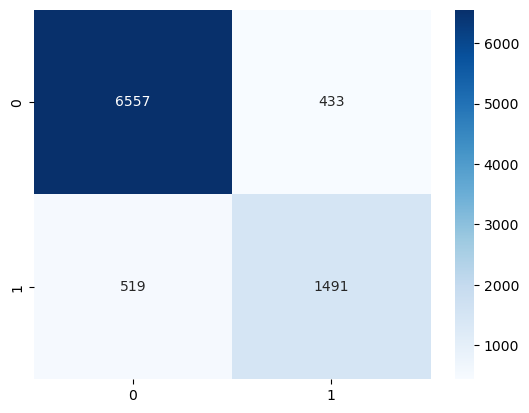

In [30]:
sns.heatmap(c_m,annot=True,fmt='d',cmap='Blues')

In [33]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.89      0.89      9000

